In [31]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test/benign/melanoma_9697.jpg
/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test/benign/melanoma_10087.jpg
/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test/benign/melanoma_9618.jpg
/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test/benign/melanoma_9614.jpg
/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test/benign/melanoma_9862.jpg
/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test/benign/melanoma_9838.jpg
/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test/benign/melanoma_9851.jpg
/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test/benign/melanoma_9691.jpg
/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test/benign/

In [32]:
import os
import cv2
import numpy as np
from tqdm import tqdm

IMG_SIZE = 150

def load_data():
    base_train = "/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/train"
    base_test  = "/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test"

    def load_from_folder(base_path):
        images = []
        labels = []

        for folder in os.listdir(base_path):
            folder_path = os.path.join(base_path, folder)
            if not os.path.isdir(folder_path):
                continue

            label = 1 if folder.lower().startswith("mal") else 0  # malignant=1, benign=0

            for file in tqdm(os.listdir(folder_path), desc=f"Loading {folder}"):
                img_path = os.path.join(folder_path, file)
                img = cv2.imread(img_path)  # BGR uint8
                if img is None:
                    continue

                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

                images.append(img)
                labels.append(label)

        images = np.array(images, dtype=np.uint8)      # keep 0..255
        labels = np.array(labels, dtype=np.int32)
        return images, labels

    train_images, train_labels = load_from_folder(base_train)
    test_images, test_labels = load_from_folder(base_test)
    return (train_images, train_labels), (test_images, test_labels)

(train_images, train_labels), (test_images, test_labels) = load_data()


Loading malignant: 100%|██████████| 500/500 [00:01<00:00, 283.47it/s]


In [33]:
print(train_images.shape, train_images.dtype)


(9605, 150, 150, 3) uint8


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

train_images, train_labels = shuffle(train_images, train_labels, random_state=42)

train_X, val_X, train_y, val_y = train_test_split(
    train_images, train_labels,
    test_size=0.2,
    random_state=42,
    stratify=train_labels
)

In [35]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow(train_X, train_y, batch_size=32, shuffle=True)
val_gen = val_datagen.flow(val_X, val_y, batch_size=32, shuffle=False)
test_gen = val_datagen.flow(test_images, test_labels, batch_size=32, shuffle=False)


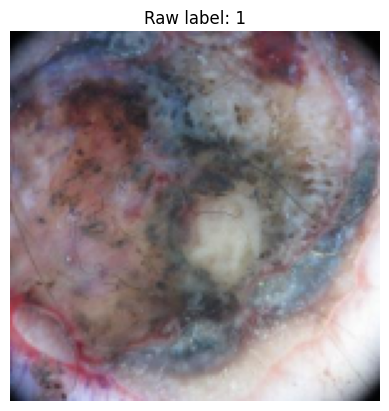

In [36]:
import matplotlib.pyplot as plt
import random

i = random.randint(0, len(train_images) - 1)
plt.imshow(train_images[i])  # uint8 0..255
plt.title(f"Raw label: {train_labels[i]}")
plt.axis("off")
plt.show()


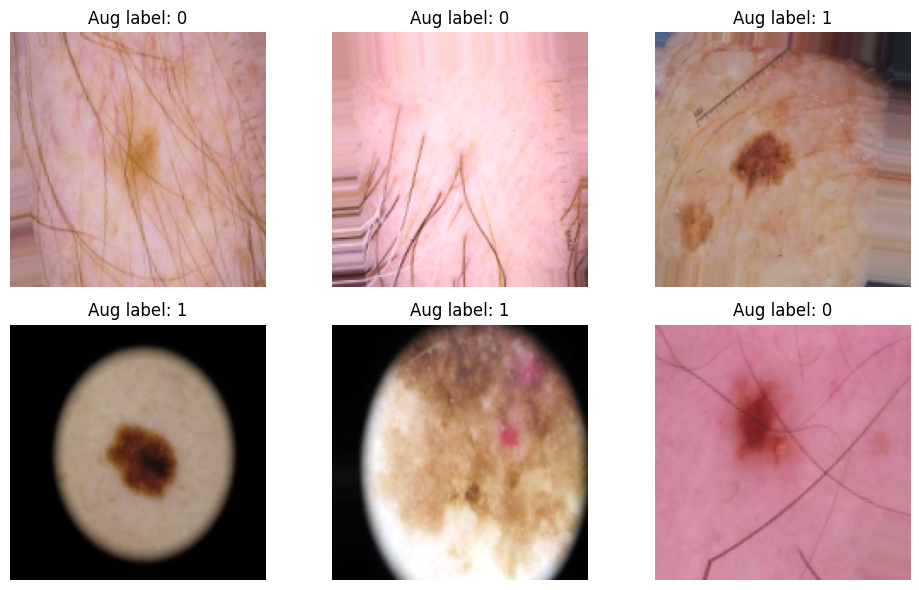

In [37]:
x_batch, y_batch = next(train_generator)

plt.figure(figsize=(10, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(x_batch[i])  # float 0..1
    plt.axis("off")
    plt.title(f"Aug label: {int(y_batch[i])}")
plt.tight_layout()
plt.show()


In [38]:
import tensorflow as tf
from tensorflow.keras import layers, models



model = models.Sequential([
        layers.Input(shape=(150, 150, 3)),

    layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")   # binary output
])

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     5,308,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,697,345 (21.73 MB)

 Trainable params: 5,697,345 (21.73 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]


In [40]:

history = model.fit(
    train_generator,
    validation_data=val_gen,
    epochs=18,
    callbacks=callbacks
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/18
241/241 ━━━━━━━━━━━━━━━━━━━━ 296s 1s/step - accuracy: 0.6818 - auc: 0.7523 - loss: 0.5654 - val_accuracy: 0.8699 - val_auc: 0.9492 - val_loss: 0.3120 - learning_rate: 1.0000e-04
Epoch 2/18
241/241 ━━━━━━━━━━━━━━━━━━━━ 296s 1s/step - accuracy: 0.8514 - auc: 0.9212 - loss: 0.3532 - val_accuracy: 0.8865 - val_auc: 0.9540 - val_loss: 0.3043 - learning_rate: 1.0000e-04
Epoch 3/18
241/241 ━━━━━━━━━━━━━━━━━━━━ 293s 1s/step - accuracy: 0.8548 - auc: 0.9262 - loss: 0.3416 - val_accuracy: 0.8954 - val_auc: 0.9562 - val_loss: 0.2797 - learning_rate: 1.0000e-04
Epoch 4/18
241/241 ━━━━━━━━━━━━━━━━━━━━ 305s 1s/step - accuracy: 0.8631 - auc: 0.9329 - loss: 0.3261 - val_accuracy: 0.8860 - val_auc: 0.9616 - val_loss: 0.2633 - learning_rate: 1.0000e-04
Epoch 5/18
241/241 ━━━━━━━━━━━━━━━━━━━━ 311s 1s/step - accuracy: 0.8755 - auc: 0.9437 - loss: 0.2997 - val_accuracy: 0.8990 - val_auc: 0.9654 - val_loss: 0.2414 - learning_rate: 1.0000e-04
Epoch 6/18
241/241 ━━━━━━━━━━━━━━━━━━━━ 303s 1s/step - 

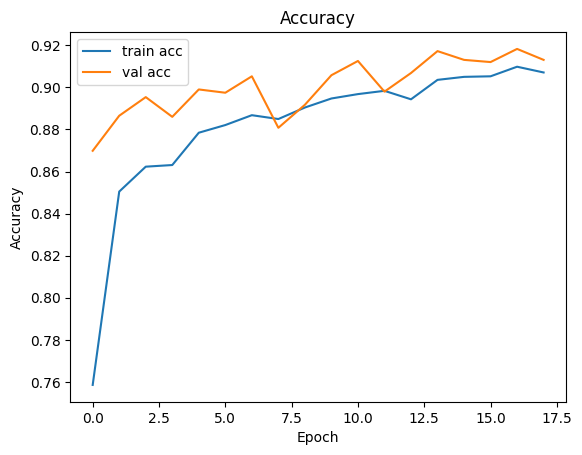

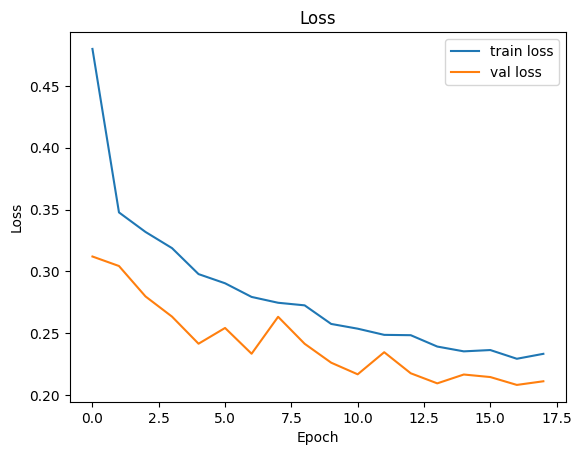

In [41]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc") 
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.figure()
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss")
plt.show()



Test Loss: 0.21997912228107452
Test Accuracy: 0.9049999713897705
Test AUC: 0.9706560373306274

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.89      0.92      0.91       500
malignant (1)       0.92      0.89      0.90       500

     accuracy                           0.91      1000
    macro avg       0.91      0.91      0.90      1000
 weighted avg       0.91      0.91      0.90      1000



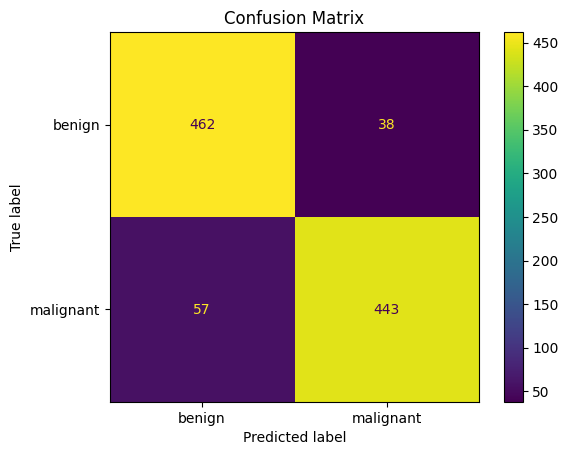

In [42]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

test_loss, test_acc, test_auc = model.evaluate(test_gen, verbose=0)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)
print("Test AUC:", test_auc)


y_prob = model.predict(test_gen, verbose=0).ravel()

y_true = test_labels

y_pred = (y_prob >= 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["benign (0)", "malignant (1)"]))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["benign", "malignant"])
disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.show()


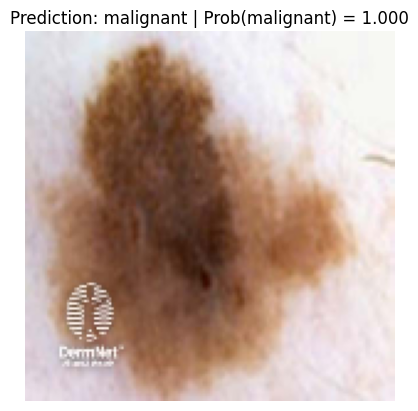

In [43]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 150

image_path = "/kaggle/input/test-image/mel-irreg2-sm.jpg" 

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))


x = img.astype(np.float32) / 255.0
x = np.expand_dims(x, axis=0)


prob = model.predict(x, verbose=0)[0][0]
pred = "malignant" if prob >= 0.5 else "benign"


plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {pred} | Prob(malignant) = {prob:.3f}")
plt.show()